### Experiment Design
This study explores various approaches for forecasting **wave height over the next 12 hours**, considering different input configurations and forecasting strategies.

#### Input Configurations
- **Baseline**: Previous hour's wave height as the prediction
- **Case 1**: Past n-hour wind features
- **Case 2**: Past n-hour wave heights
- **Case 3**: Past n-hour wind features + Past n-hour wave heights
- **Case 4**: Past n-hour wind features + Future 12-hour wind features
- **Case 5**: Past n-hour wind features + Future 12-hour wind features + Past n-hour wave heights

#### Experiments
- **Experiment 1**: Direct prediction of wave height over the next 12 hours
- **Experiment 2**: Rolling forecast with hourly updates across the 12-hour horizon
- **Experiment 3**: Explore different historical input window lengths on model performance
- **Experiment 4**: Explore impact of wind forecast uncertainty on model performance

#### Further Model Optimization
- **Hyperparameters Tuning**
- **Bidirectional LSTM**: Incorporates both past and future temporal dependencies to improve prediction accuracy

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.legend_handler import HandlerTuple

outputs = list(range(1, 13))

# Baseline
test_rmse_base = [0.235, 0.364, 0.464, 0.550, 0.623, 0.687, 0.745, 0.796, 0.841, 0.880, 0.914, 0.946]

# Experiment 1
train_rmse_1_1 = [0.623, 0.641, 0.664, 0.687, 0.710, 0.730, 0.749, 0.772, 0.789, 0.806, 0.823, 0.837]
test_rmse_1_1 = [0.383, 0.433, 0.490, 0.541, 0.588, 0.621, 0.654, 0.690, 0.716, 0.743, 0.767, 0.786]

train_rmse_1_2 = [0.338, 0.419, 0.488, 0.551, 0.603, 0.649, 0.687, 0.720, 0.748, 0.771, 0.791, 0.811]
test_rmse_1_2 = [0.243, 0.356, 0.441, 0.519, 0.581, 0.635, 0.681, 0.718, 0.748, 0.773, 0.794, 0.816]

train_rmse_1_3 = [0.337, 0.408, 0.473, 0.527, 0.576, 0.618, 0.655, 0.689, 0.717, 0.743, 0.764, 0.786]
test_rmse_1_3 = [0.237, 0.342, 0.425, 0.496, 0.556, 0.605, 0.650, 0.689, 0.720, 0.748, 0.770, 0.793]

train_rmse_1_4 = [0.442, 0.424, 0.413, 0.406, 0.402, 0.397, 0.399, 0.401, 0.408, 0.414, 0.426, 0.450]
test_rmse_1_4 = [0.339, 0.332, 0.336, 0.338, 0.337, 0.338, 0.325, 0.329, 0.321, 0.328, 0.326, 0.343]

train_rmse_1_5 = [0.348, 0.375, 0.408, 0.430, 0.451, 0.461, 0.472, 0.480, 0.489, 0.499, 0.506, 0.522]
test_rmse_1_5 = [0.217, 0.226, 0.246, 0.258, 0.266, 0.268, 0.268, 0.264, 0.270, 0.272, 0.276, 0.297]

# Experiment 2
test_rmse_2_1 = [0.471, 0.484, 0.509, 0.542, 0.578, 0.616, 0.652, 0.687, 0.722, 0.753, 0.782, 0.808]
test_rmse_2_2 = [0.328, 0.557, 0.751, 0.894, 0.971, 0.978, 0.954, 0.932, 0.923, 0.926, 0.932, 0.937]
test_rmse_2_3 = [0.332, 0.521, 0.625, 0.683, 0.712, 0.721, 0.737, 0.753, 0.770, 0.788, 0.805, 0.822]
test_rmse_2_4 = [0.572, 0.530, 0.492, 0.459, 0.436, 0.422, 0.420, 0.429, 0.450, 0.479, 0.515, 0.555]
test_rmse_2_5 = [0.473, 0.562, 0.560, 0.567, 0.560, 0.563, 0.586, 0.615, 0.658, 0.701, 0.716, 0.837]

# Experiment 3
test_rmse_3_1 = [0.193, 0.222, 0.244, 0.252, 0.266, 0.278, 0.288, 0.297, 0.286, 0.289, 0.287, 0.296]
test_rmse_3_2 = [0.184, 0.206, 0.223, 0.236, 0.242, 0.246, 0.252, 0.256, 0.257, 0.264, 0.265, 0.274]
test_rmse_3_3 = [0.177, 0.205, 0.225, 0.230, 0.236, 0.246, 0.249, 0.256, 0.246, 0.251, 0.249, 0.254]
test_rmse_3_4 = [0.225, 0.232, 0.248, 0.245, 0.257, 0.242, 0.240, 0.243, 0.244, 0.247, 0.249, 0.256]
test_rmse_3_5 = [0.208, 0.218, 0.224, 0.238, 0.238, 0.238, 0.243, 0.244, 0.250, 0.257, 0.252, 0.261]
test_rmse_3_6 = [0.202, 0.220, 0.228, 0.229, 0.235, 0.244, 0.246, 0.243, 0.244, 0.243, 0.250, 0.250]
test_rmse_3_7 = [0.180, 0.210, 0.225, 0.229, 0.234, 0.241, 0.247, 0.250, 0.248, 0.245, 0.247, 0.251]

# Experiment 4
test_rmse_4_1 = [0.226, 0.346, 0.460, 0.532, 0.592, 0.659, 0.726, 0.779, 0.834, 0.874, 0.904, 0.956]
test_rmse_4_2 = [0.207, 0.291, 0.385, 0.370, 0.294, 0.312, 0.355, 0.462, 0.587, 0.525, 0.423, 0.427]
test_rmse_4_3 = [0.199, 0.272, 0.351, 0.332, 0.267, 0.285, 0.323, 0.427, 0.539, 0.476, 0.384, 0.391]

# Model optimization
test_rmse_LSTM = [0.176, 0.206, 0.223, 0.235, 0.238, 0.241, 0.244, 0.248, 0.241, 0.235, 0.236, 0.247]
test_rmse_BiLSTM = [0.184, 0.207, 0.234, 0.240, 0.244, 0.262, 0.270, 0.269, 0.258, 0.260, 0.251, 0.255]
test_rmse_LSTM_noise = [0.222, 0.278, 0.304, 0.310, 0.300, 0.304, 0.344, 0.418, 0.447, 0.449, 0.422, 0.402]
test_rmse_BiLSTM_noise = [0.202, 0.242, 0.270, 0.274, 0.263, 0.288, 0.354, 0.469, 0.509, 0.515, 0.430, 0.407]

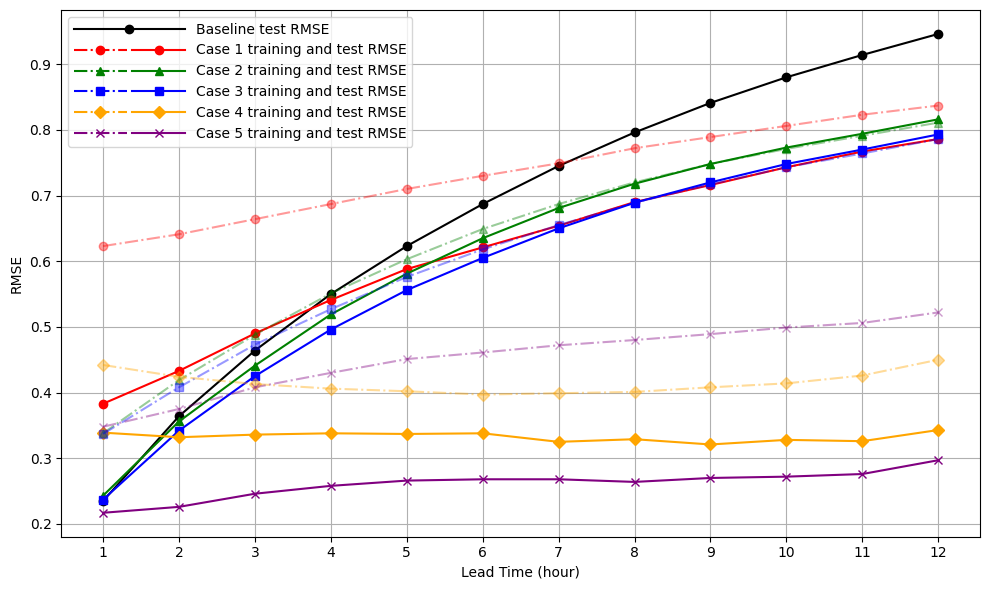

In [2]:
plt.figure(figsize=(10, 6))
plt.plot(outputs, test_rmse_base, color='k', linestyle='-', marker='o')

plt.plot(outputs, test_rmse_1_1, color='r', linestyle='-', marker='o')
plt.plot(outputs, test_rmse_1_2, color='g', linestyle='-', marker='^')
plt.plot(outputs, test_rmse_1_3, color='b', linestyle='-', marker='s')
plt.plot(outputs, test_rmse_1_4, color='orange', linestyle='-', marker='D')
plt.plot(outputs, test_rmse_1_5, color='purple', linestyle='-', marker='x')

plt.plot(outputs, train_rmse_1_1, color='r', linestyle='-.', marker='o', alpha=0.4)
plt.plot(outputs, train_rmse_1_2, color='g', linestyle='-.', marker='^', alpha=0.4)
plt.plot(outputs, train_rmse_1_3, color='b', linestyle='-.', marker='s', alpha=0.4)
plt.plot(outputs, train_rmse_1_4, color='orange', linestyle='-.', marker='D', alpha=0.4)
plt.plot(outputs, train_rmse_1_5, color='purple', linestyle='-.', marker='x', alpha=0.4)

elements = [
    (Line2D([0], [0], color='k', linestyle='-', marker='o'), 'Baseline test RMSE'),
    ((Line2D([0], [0], color='r', linestyle='-.', marker='o'), Line2D([0], [0], color='r', linestyle='-', marker='o')), 'Case 1 training and test RMSE'),
    ((Line2D([0], [0], color='g', linestyle='-.', marker='^'), Line2D([0], [0], color='g', linestyle='-', marker='^')), 'Case 2 training and test RMSE'),
    ((Line2D([0], [0], color='b', linestyle='-.', marker='s'), Line2D([0], [0], color='b', linestyle='-', marker='s')), 'Case 3 training and test RMSE'),
    ((Line2D([0], [0], color='orange', linestyle='-.', marker='D'), Line2D([0], [0], color='orange', linestyle='-', marker='D')), 'Case 4 training and test RMSE'),
    ((Line2D([0], [0], color='purple', linestyle='-.', marker='x'), Line2D([0], [0], color='purple', linestyle='-', marker='x')), 'Case 5 training and test RMSE')]

handles = [pair[0] for pair in elements]
labels = [pair[1] for pair in elements]
plt.legend(handles, labels, handler_map={tuple: HandlerTuple(ndivide=None)}, handlelength=8, loc='best')
plt.xticks(outputs)
plt.xlabel('Lead Time (hour)')
plt.ylabel('RMSE')
plt.grid(True)
plt.tight_layout()
# plt.savefig('exp_1.png', dpi=1200, format='png')
plt.show()

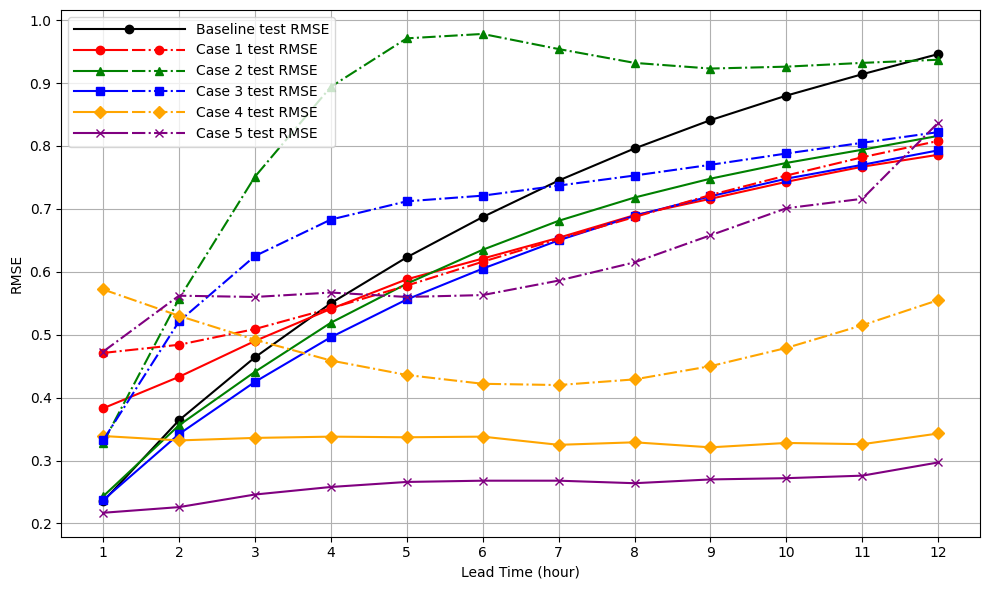

In [3]:
plt.figure(figsize=(10, 6))
plt.plot(outputs, test_rmse_base, color='k', linestyle='-', marker='o')

plt.plot(outputs, test_rmse_1_1, color='r', linestyle='-', marker='o')
plt.plot(outputs, test_rmse_1_2, color='g', linestyle='-', marker='^')
plt.plot(outputs, test_rmse_1_3, color='b', linestyle='-', marker='s')
plt.plot(outputs, test_rmse_1_4, color='orange', linestyle='-', marker='D')
plt.plot(outputs, test_rmse_1_5, color='purple', linestyle='-', marker='x')

plt.plot(outputs, test_rmse_2_1, color='r', linestyle='-.', marker='o')
plt.plot(outputs, test_rmse_2_2, color='g', linestyle='-.', marker='^')
plt.plot(outputs, test_rmse_2_3, color='b', linestyle='-.', marker='s')
plt.plot(outputs, test_rmse_2_4, color='orange', linestyle='-.', marker='D')
plt.plot(outputs, test_rmse_2_5, color='purple', linestyle='-.', marker='x')

elements = [
    (Line2D([0], [0], color='k', linestyle='-', marker='o'), 'Baseline test RMSE'),
    ((Line2D([0], [0], color='r', linestyle='-', marker='o'), Line2D([0], [0], color='r', linestyle='-.', marker='o')), 'Case 1 test RMSE'),
    ((Line2D([0], [0], color='g', linestyle='-', marker='^'), Line2D([0], [0], color='g', linestyle='-.', marker='^')), 'Case 2 test RMSE'),
    ((Line2D([0], [0], color='b', linestyle='-', marker='s'), Line2D([0], [0], color='b', linestyle='-.', marker='s')), 'Case 3 test RMSE'),
    ((Line2D([0], [0], color='orange', linestyle='-', marker='D'), Line2D([0], [0], color='orange', linestyle='-.', marker='D')), 'Case 4 test RMSE'),
    ((Line2D([0], [0], color='purple', linestyle='-', marker='x'), Line2D([0], [0], color='purple', linestyle='-.', marker='x')), 'Case 5 test RMSE')]

handles = [pair[0] for pair in elements]
labels = [pair[1] for pair in elements]
plt.legend(handles, labels, handler_map={tuple: HandlerTuple(ndivide=None)}, handlelength=8, loc='best')
plt.xticks(outputs)
plt.xlabel('Lead Time (hour)')
plt.ylabel('RMSE')
plt.grid(True)
plt.tight_layout()
# plt.savefig('exp_2.png', dpi=1200, format='png')
plt.show()

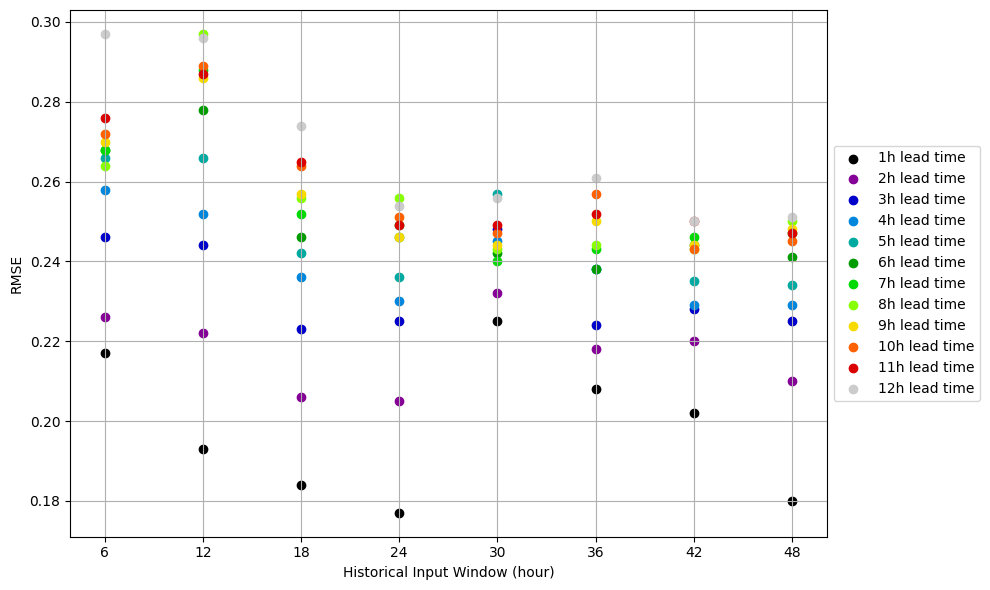

In [4]:
rmse_arr = np.array([test_rmse_1_5, test_rmse_3_1, test_rmse_3_2, test_rmse_3_3,
                     test_rmse_3_4, test_rmse_3_5, test_rmse_3_6, test_rmse_3_7])

plt.figure(figsize=(10, 6))
cmap = plt.get_cmap('nipy_spectral', 12)
colors = [cmap(i) for i in range(12)]
for i in range(12):
    plt.scatter(np.arange(6, 50, 6), rmse_arr[:, i], color=colors[i], marker='o', label=f'{i+1}h lead time')

plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.xticks(np.arange(6, 50, 6))
plt.xlabel('Historical Input Window (hour)')
plt.ylabel('RMSE')
plt.grid(True)
plt.tight_layout()
# plt.savefig('exp_3.png', dpi=1200, format='png')
plt.show()

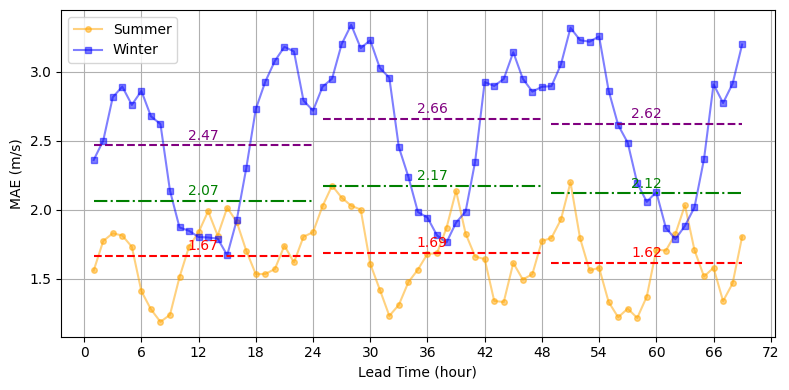

In [5]:
var, unit = 'WSPD', 'm/s'
# var, unit = 'WDIR', 'deg'

df = pd.read_csv('wind_uncertainty.csv')

plt.figure(figsize=(8, 4))
plt.plot(df['lead_time'], df[var + '_MAE_summer'], color='orange', marker='o', markersize=4, alpha=0.5, label='Summer')
plt.plot(df['lead_time'], df[var + '_MAE_winter'], color='b', marker='s', markersize=4, alpha=0.5, label='Winter')
for i in range(3):
    seg = df.iloc[24*i:24*(i+1)]
    summer_avg = seg[var + '_MAE_summer'].mean()
    winter_avg = seg[var + '_MAE_winter'].mean()
    annual_avg = (seg[var + '_MAE_summer'] + seg[var + '_MAE_winter']).mean() / 2
    plt.hlines(summer_avg, seg['lead_time'].min(), seg['lead_time'].max(), colors='r', linestyles='--')
    plt.text((seg['lead_time'].min() + seg['lead_time'].max()) / 2, summer_avg + 0.02, f'{summer_avg:.2f}', color='r', ha='center', va='bottom')
    plt.hlines(winter_avg, seg['lead_time'].min(), seg['lead_time'].max(), colors='purple', linestyles='--')
    plt.text((seg['lead_time'].min() + seg['lead_time'].max()) / 2, winter_avg + 0.02, f'{winter_avg:.2f}', color='purple', ha='center', va='bottom')
    plt.hlines(annual_avg, seg['lead_time'].min(), seg['lead_time'].max(), colors='g', linestyles='-.')
    plt.text((seg['lead_time'].min() + seg['lead_time'].max()) / 2, annual_avg + 0.02, f'{annual_avg:.2f}', color='g', ha='center', va='bottom')

plt.legend()
plt.xticks(np.arange(0, 73, 6))
plt.xlabel('Lead Time (hour)')
plt.ylabel('MAE (' + unit + ')')
plt.grid(True)
plt.tight_layout()
# plt.savefig(var + '_uncertainty.png', dpi=1200, format='png')
plt.show()

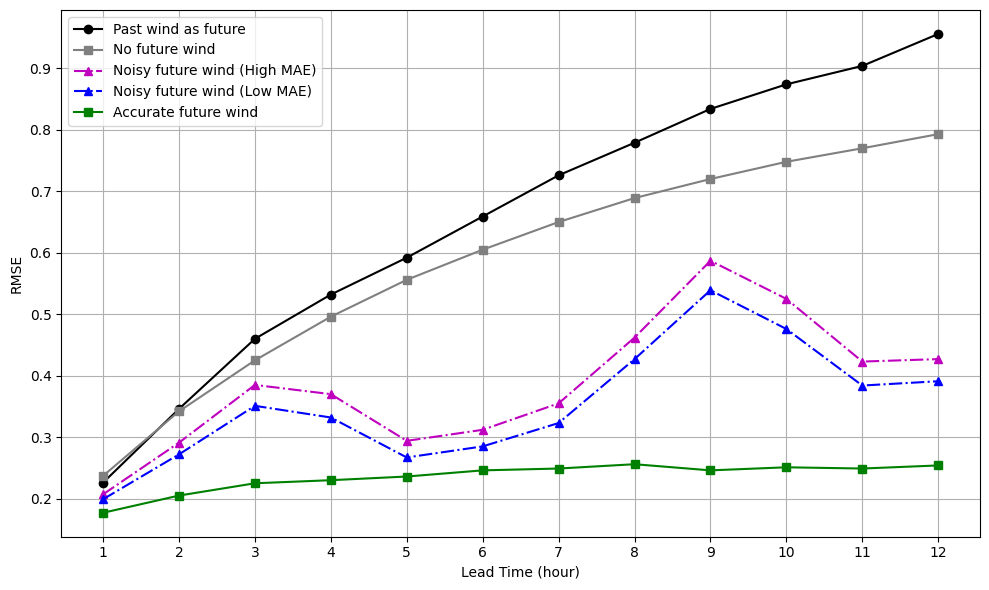

In [6]:
plt.figure(figsize=(10, 6))
plt.plot(outputs, test_rmse_4_1, color='k', marker='o', label='Past wind as future')
plt.plot(outputs, test_rmse_1_3, color='gray', marker='s', label='No future wind')
plt.plot(outputs, test_rmse_4_2, color='m', marker='^', linestyle='-.', label='Noisy future wind (High MAE)')
plt.plot(outputs, test_rmse_4_3, color='b', marker='^', linestyle='-.', label='Noisy future wind (Low MAE)')
plt.plot(outputs, test_rmse_3_3, color='g', marker='s', label='Accurate future wind')

plt.legend()
plt.xticks(outputs)
plt.xlabel('Lead Time (hour)')
plt.ylabel('RMSE')
plt.grid(True)
plt.tight_layout()
# plt.savefig('exp_4.png', dpi=1200, format='png')
plt.show()

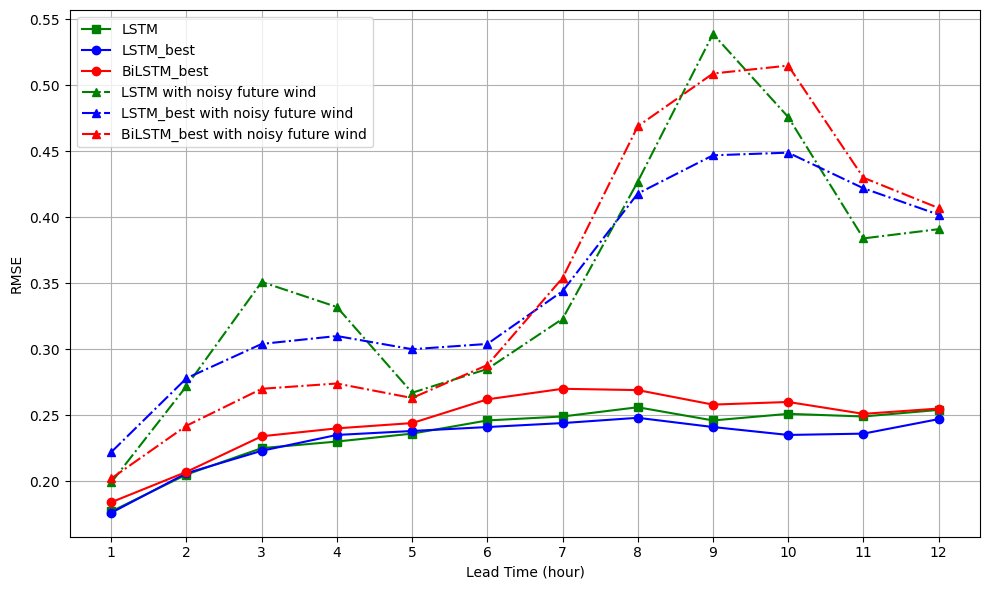

In [7]:
plt.figure(figsize=(10, 6))
plt.plot(outputs, test_rmse_3_3, color='g', marker='s', label='LSTM')
plt.plot(outputs, test_rmse_LSTM, color='b', marker='o', label='LSTM_best')
plt.plot(outputs, test_rmse_BiLSTM, color='r', marker='o', label='BiLSTM_best')
plt.plot(outputs, test_rmse_4_3, color='g', marker='^', linestyle='-.', label='LSTM with noisy future wind')
plt.plot(outputs, test_rmse_LSTM_noise, color='b', marker='^', linestyle='-.', label='LSTM_best with noisy future wind')
plt.plot(outputs, test_rmse_BiLSTM_noise, color='r', marker='^', linestyle='-.', label='BiLSTM_best with noisy future wind')

plt.legend()
plt.xticks(outputs)
plt.xlabel('Lead Time (hour)')
plt.ylabel('RMSE')
plt.grid(True)
plt.tight_layout()
# plt.savefig('model_opt.png', dpi=1200, format='png')
plt.show()